# 🫘 Kidney Stone Images Classification using Deep Learning

**Dataset:** https://www.kaggle.com/datasets/safurahajiheidari/kidney-stone-images  
**Models:** Xception | InceptionV3 | EfficientNetV2S | ConvNeXt-Tiny  
**Task:** Binary Classification - Small Stone vs Large Stone  
**Platform:** Kaggle Notebook (T4 GPU)

---
### Dataset Notes
All images contain kidney stones (`nc: 1`, class `Tas_Var`).  
Classification uses the **largest bounding box area** per image with a median split:
- **Class 0 — `small`**: max stone area < dataset median  
- **Class 1 — `large`**: max stone area ≥ dataset median  

Large stones occupy a visually greater portion of the CT image, giving the models more learnable signal than stone count.

---

##  Cell 1 - Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import (
    Xception, InceptionV3, EfficientNetV2S, ConvNeXtTiny
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, cohen_kappa_score, roc_curve
)

print(f'TensorFlow : {tf.__version__}')
print(f'GPUs found : {tf.config.list_physical_devices("GPU")}')

DATASET_PATH = '/kaggle/input/datasets/safurahajiheidari/kidney-stone-images'
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 20
SEED         = 42
CLASS_NAMES  = ['small', 'large']   # 0 = small stone, 1 = large stone

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Setup complete.')

2026-06-02 06:43:35.260947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780382615.477762      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780382615.541506      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780382616.079545      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780382616.079587      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780382616.079590      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Setup complete.


##  Cell 2 - Dataset Structure Check + Auto-detect Path

In [2]:
# ── Step 1: Show everything under /kaggle/input ─────────────
print('=== /kaggle/input FULL STRUCTURE ===')
for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.replace('/kaggle/input', '').count(os.sep)
    if depth > 4:
        continue
    print('  ' * depth + os.path.basename(root) + '/')
    if depth >= 3:
        for f in files[:2]:
            print('  ' * (depth+1) + f)
        if len(files) > 2:
            print('  ' * (depth+1) + f'... ({len(files)} files)')

# ── Step 2: Auto-detect the folder that contains train/valid/test ──
DATASET_PATH = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:          # Priority 1: Roboflow standard marker
        DATASET_PATH = root
        break
    if 'train' in dirs:               # Priority 2: contains train/ subfolder
        DATASET_PATH = root
        break

if DATASET_PATH is None:
    raise FileNotFoundError(
        'Dataset not found. Make sure you added it via + Add Data in Kaggle.'
    )

print(f'\n✅ DATASET_PATH auto-detected: {DATASET_PATH}')

# ── Step 3: Print data.yaml ──────────────────────────────────
yaml_path = os.path.join(DATASET_PATH, 'data.yaml')
if os.path.exists(yaml_path):
    print('\n=== data.yaml ===')
    with open(yaml_path) as f:
        print(f.read())

=== /kaggle/input FULL STRUCTURE ===
input/
  datasets/
    safurahajiheidari/
      kidney-stone-images/
        README.dataset.txt
        README.roboflow.txt
        ... (3 files)
        valid/
        test/
        train/

✅ DATASET_PATH auto-detected: /kaggle/input/datasets/safurahajiheidari/kidney-stone-images

=== data.yaml ===
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Tas_Var']

roboflow:
  workspace: tez-nwkf5
  project: tez_roi_aug
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/tez-nwkf5/tez_roi_aug/dataset/3


##  Cell 3 - Parse YOLO Labels → Build DataFrame (Stone Size Classification)

In [3]:
def parse_yolo_label(label_path):
    """Parse YOLO .txt file. Returns list of annotation dicts."""
    annotations = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.read().strip().split('\n'):
                parts = line.strip().split()
                if len(parts) >= 5:
                    annotations.append({
                        'class_id': int(parts[0]),
                        'x_center': float(parts[1]),
                        'y_center': float(parts[2]),
                        'width'   : float(parts[3]),
                        'height'  : float(parts[4]),
                        'area'    : float(parts[3]) * float(parts[4])
                    })
    return annotations


all_data = []

for split in ['train', 'valid', 'test']:
    images_dir = os.path.join(DATASET_PATH, split, 'images')
    labels_dir = os.path.join(DATASET_PATH, split, 'labels')

    if not os.path.exists(images_dir):
        print(f'  Skipping {split!r} — not found')
        continue

    for fname in os.listdir(images_dir):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path   = os.path.join(images_dir, fname)
        label_file = os.path.splitext(fname)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)
        annots     = parse_yolo_label(label_path)
        cnt        = len(annots)
        max_area   = max((a['area'] for a in annots), default=0.0)

        all_data.append({
            'image_path' : img_path,
            'split'      : split,
            'stone_count': cnt,
            'max_area'   : max_area,
            'annotations': annots
        })

df = pd.DataFrame(all_data)
df = df[df['stone_count'] > 0].reset_index(drop=True)

# ── Median split on largest bounding box area ─────────────────
median_area       = df['max_area'].median()
df['label']     = df['max_area'].apply(lambda x: 'large' if x >= median_area else 'small')
df['label_int'] = df['max_area'].apply(lambda x: 1       if x >= median_area else 0)

print(f'Total images        : {len(df)}')
print(f'Median stone area   : {median_area:.5f} (normalised bbox area)')
print(f'Area range          : [{df["max_area"].min():.5f}, {df["max_area"].max():.5f}]')
print(f'\nSplit distribution:')
print(df['split'].value_counts())
print(f'\nClass distribution (small vs large stone):')
print(df['label'].value_counts())
df[['image_path','split','stone_count','max_area','label','label_int']].head()


Total images        : 1299
Median stone area   : 0.00152 (normalised bbox area)
Area range          : [0.00012, 0.16753]

Split distribution:
split
train    1053
valid     123
test      123
Name: count, dtype: int64

Class distribution (small vs large stone):
label
large    650
small    649
Name: count, dtype: int64


,image_path,split,stone_count,max_area,label,label_int
0,/kaggle/input/datasets/safurahajiheidari/kidne...,train,1,0.005179,large,1
1,/kaggle/input/datasets/safurahajiheidari/kidne...,train,1,0.001798,large,1
2,/kaggle/input/datasets/safurahajiheidari/kidne...,train,5,0.004212,large,1
3,/kaggle/input/datasets/safurahajiheidari/kidne...,train,1,0.003037,large,1
4,/kaggle/input/datasets/safurahajiheidari/kidne...,train,4,0.011685,large,1


##  Cell 4 - EDA: Overview

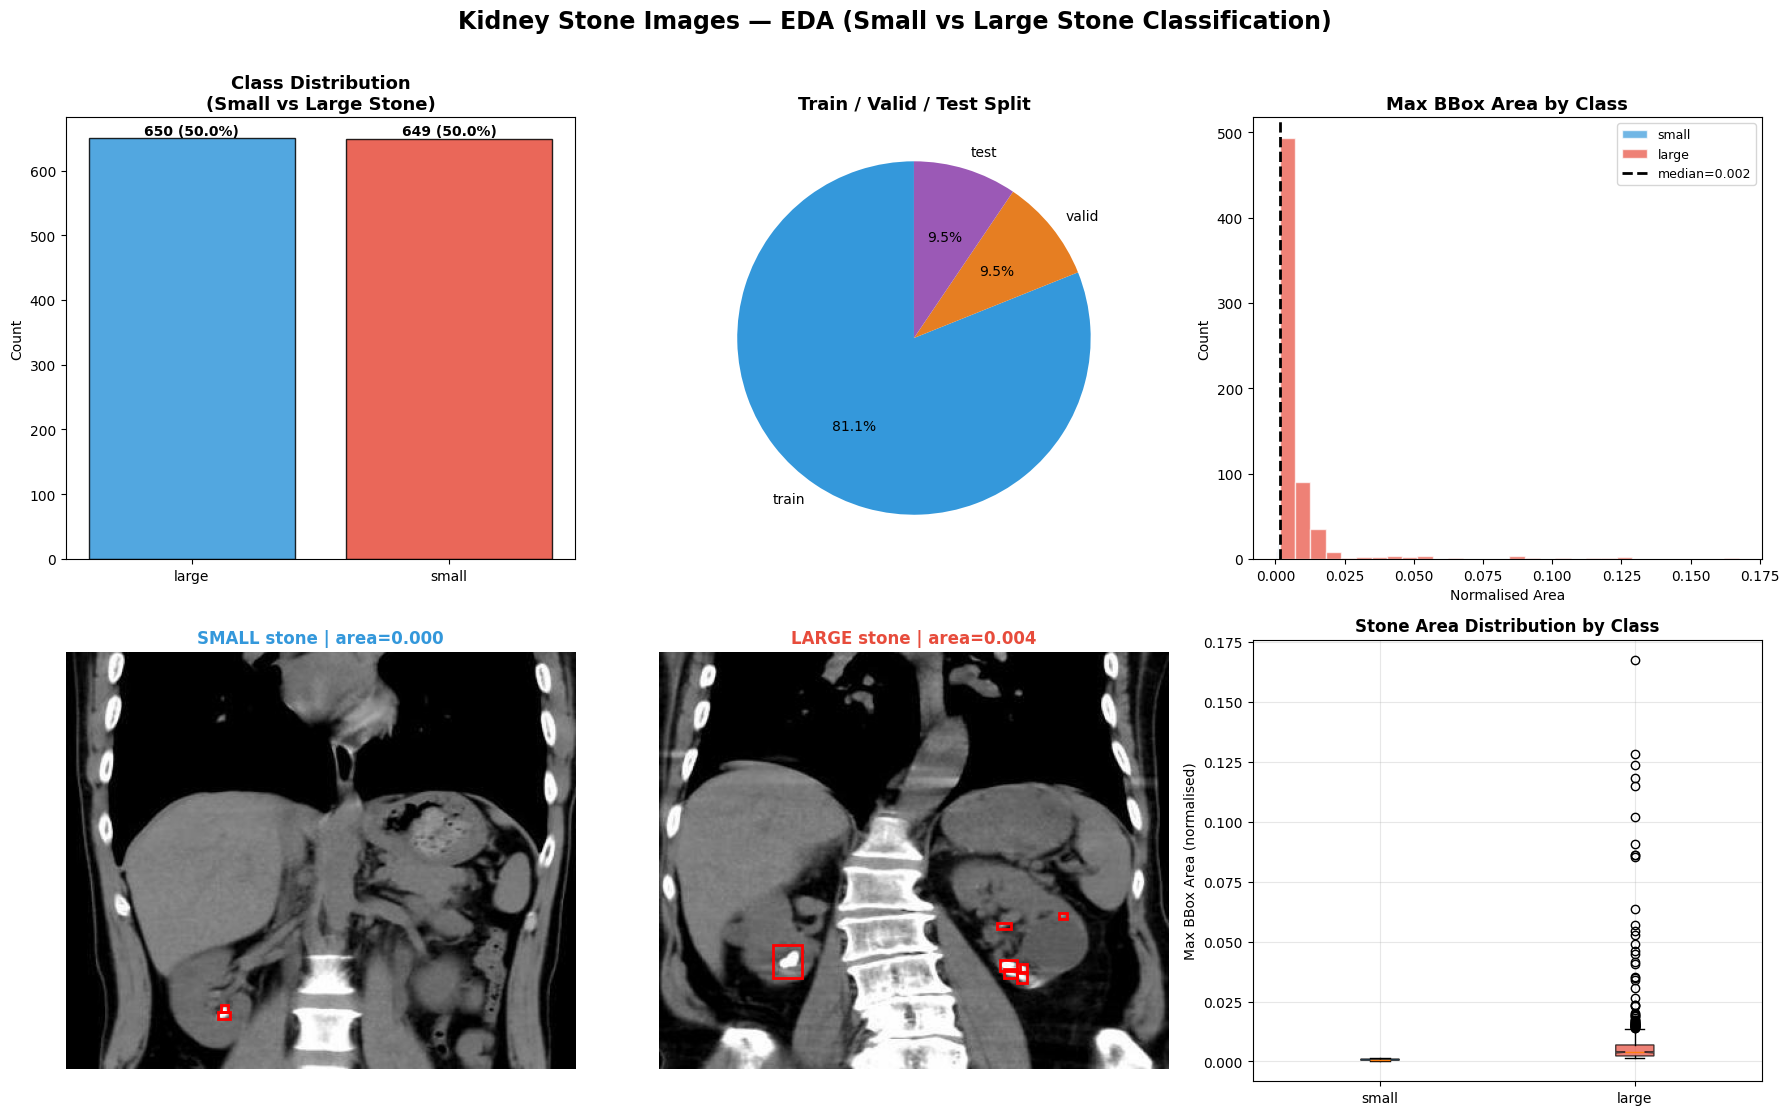

Saved: eda_overview.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Kidney Stone Images — EDA (Small vs Large Stone Classification)', fontsize=17,
             fontweight='bold', y=1.01)

# 1. Class distribution
ax  = axes[0, 0]
vc  = df['label'].value_counts()
bars = ax.bar(vc.index, vc.values,
              color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Class Distribution\n(Small vs Large Stone)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{v} ({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# 2. Split pie
ax = axes[0, 1]
sc = df['split'].value_counts()
ax.pie(sc.values, labels=sc.index, autopct='%1.1f%%', startangle=90,
       colors=['#3498db', '#e67e22', '#9b59b6'])
ax.set_title('Train / Valid / Test Split', fontsize=13, fontweight='bold')

# 3. Stone max area distribution with median line
ax = axes[0, 2]
ax.hist(df[df['label']=='small']['max_area'], bins=30,
        color='#3498db', alpha=0.7, label='small', edgecolor='white')
ax.hist(df[df['label']=='large']['max_area'], bins=30,
        color='#e74c3c', alpha=0.7, label='large', edgecolor='white')
ax.axvline(df['max_area'].median(), color='black', linestyle='--',
           linewidth=2, label=f'median={df["max_area"].median():.3f}')
ax.set_title('Max BBox Area by Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Normalised Area')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# 4-5. Sample images: one small, one large
for i, lbl in enumerate(['small', 'large']):
    ax    = axes[1, i]
    row   = df[df['label'] == lbl].sample(1, random_state=SEED+i).iloc[0]
    img   = plt.imread(row['image_path'])
    h, w  = img.shape[:2]
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    for ann in row['annotations']:
        xc, yc = ann['x_center'] * w, ann['y_center'] * h
        bw, bh = ann['width']   * w, ann['height']   * h
        rect   = patches.Rectangle((xc-bw/2, yc-bh/2), bw, bh,
                                    linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    color = '#3498db' if lbl == 'small' else '#e74c3c'
    ax.set_title(f'{lbl.upper()} stone | area={row["max_area"]:.3f}',
                 fontsize=12, fontweight='bold', color=color)
    ax.axis('off')

# 6. Box plot of area by class
ax = axes[1, 2]
data_to_plot = [df[df['label']=='small']['max_area'].values,
                df[df['label']=='large']['max_area'].values]
bp = ax.boxplot(data_to_plot, labels=['small', 'large'],
                patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
ax.set_title('Stone Area Distribution by Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Max BBox Area (normalised)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')

##  Cell 5 - EDA: Bounding Box Visualisation (Side by Side)

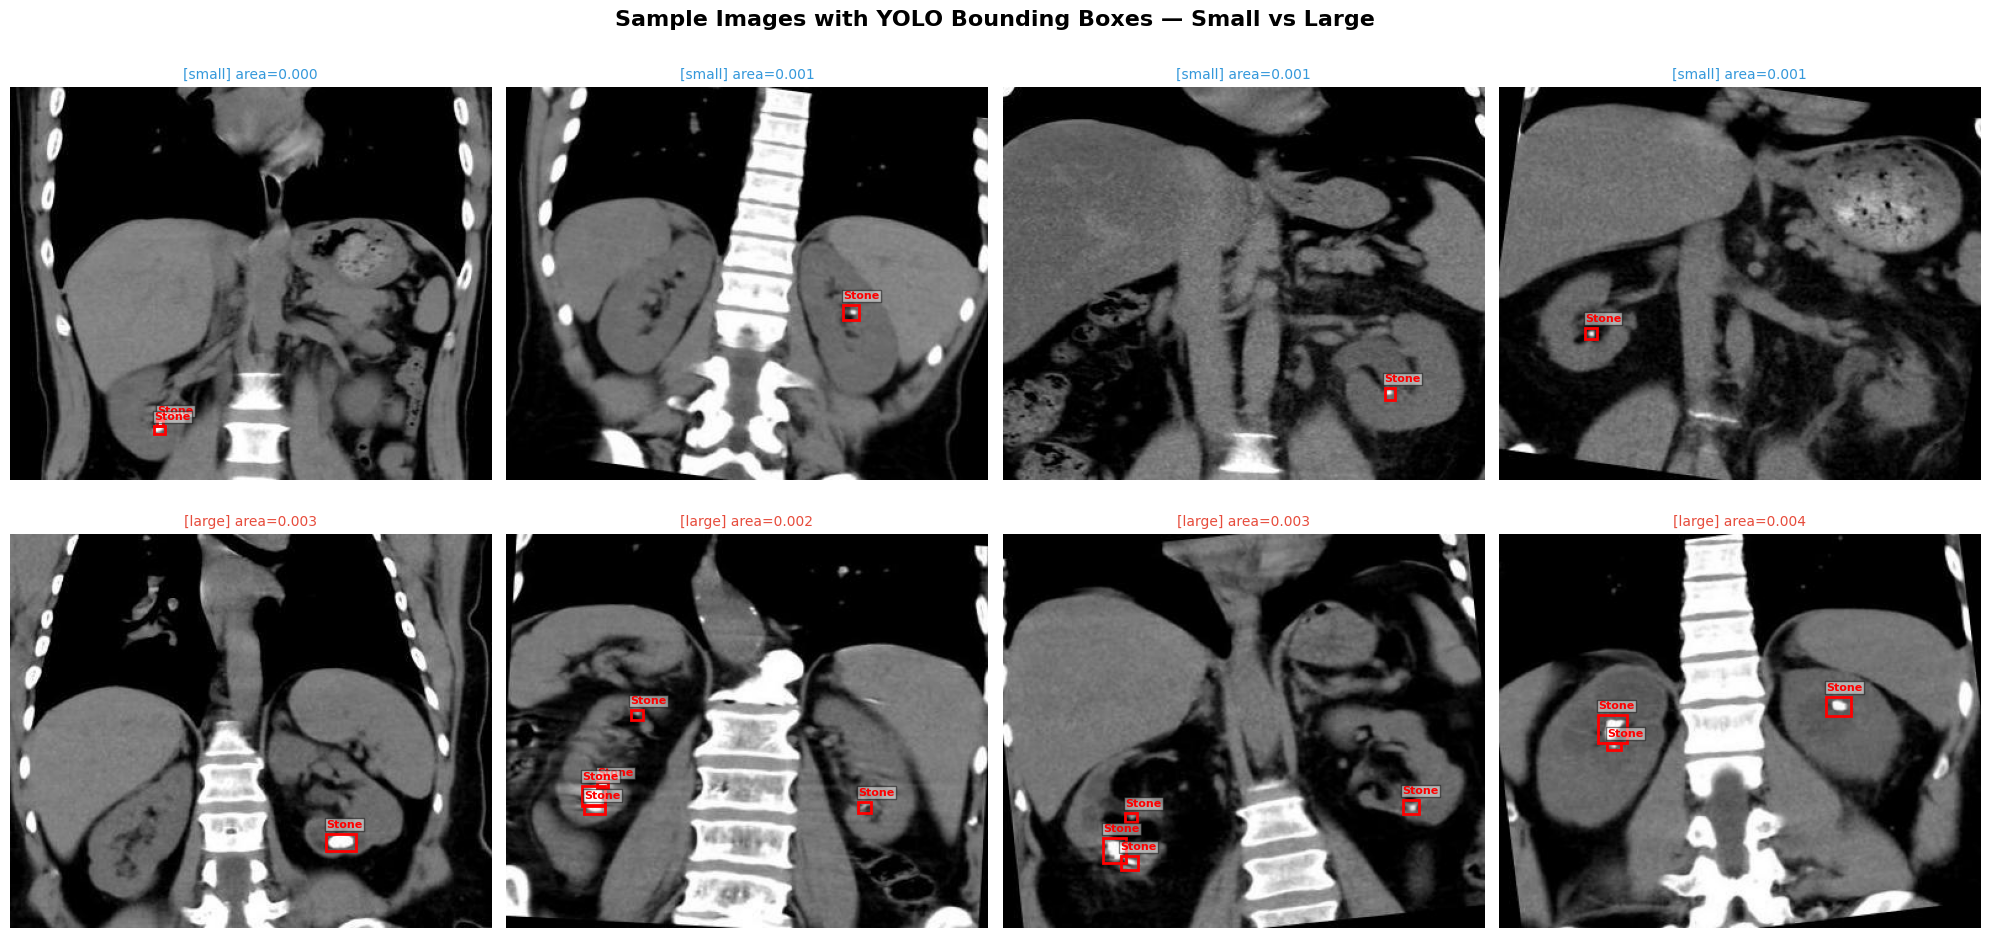

Saved: eda_bboxes.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Sample Images with YOLO Bounding Boxes — Small vs Large',
             fontsize=16, fontweight='bold')

for row_idx, lbl in enumerate(['small', 'large']):
    samples = df[df['label'] == lbl].sample(4, random_state=SEED)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax    = axes[row_idx][col_idx]
        img   = plt.imread(row['image_path'])
        h, w  = img.shape[:2]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        for ann in row['annotations']:
            xc, yc = ann['x_center'] * w, ann['y_center'] * h
            bw, bh = ann['width']   * w, ann['height']   * h
            rect   = patches.Rectangle((xc-bw/2, yc-bh/2), bw, bh,
                                        linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(xc-bw/2, max(yc-bh/2-5, 0), 'Stone',
                    color='red', fontsize=8, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.5, pad=1))
        color = '#3498db' if lbl == 'small' else '#e74c3c'
        ax.set_title(f'[{lbl}] area={row["max_area"]:.3f}',
                     fontsize=10, color=color)
        ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_bboxes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_bboxes.png')

##  Cell 6 - Class Imbalance & Class Weights

=== CLASS IMBALANCE CHECK ===
label
large    650
small    649
Name: count, dtype: int64

Imbalance ratio: 1.00x
Balanced by design (median split) — class_weight still applied as best practice.


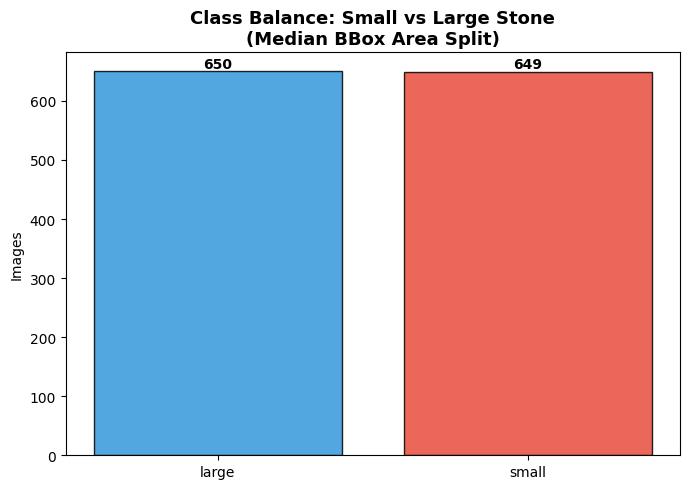


Class weights: {1: 0.9992307692307693, 0: 1.0007704160246533}


In [6]:
print('=== CLASS IMBALANCE CHECK ===')
vc    = df['label'].value_counts()
ratio = vc.max() / vc.min()
print(vc)
print(f'\nImbalance ratio: {ratio:.2f}x')

if ratio > 1.5:
    print('Imbalanced — applying class_weight during training.')
else:
    print('Balanced by design (median split) — class_weight still applied as best practice.')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(vc.index, vc.values,
              color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Class Balance: Small vs Large Stone\n(Median BBox Area Split)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Images')
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

counts_dict  = df['label_int'].value_counts().to_dict()
total        = len(df)
n_cls        = len(counts_dict)
class_weight = {k: total / (n_cls * v) for k, v in counts_dict.items()}
print(f'\nClass weights: {class_weight}')

##  Cell 7 - tf.data Pipeline

In [7]:
# Use pre-defined Roboflow splits directly
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'valid'].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

print(f'Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}')
print(f'\nTrain label distribution:')
print(train_df['label'].value_counts())
print(f'\nVal label distribution:')
print(val_df['label'].value_counts())

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_dataset(dataframe, training=False):
    paths  = dataframe['image_path'].values
    labels = dataframe['label_int'].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.cache()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, training=True)
val_ds   = build_dataset(val_df)
test_ds  = build_dataset(test_df)

for imgs, lbls in train_ds.take(1):
    print(f'\nBatch shape : {imgs.shape}')
    print(f'Pixel range : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]')
print(f'Train batches: {len(train_ds)}  |  Val batches: {len(val_ds)}')

Train : 1053  |  Val : 123  |  Test : 123

Train label distribution:
label
small    527
large    526
Name: count, dtype: int64

Val label distribution:
label
large    62
small    61
Name: count, dtype: int64


I0000 00:00:1780382649.380464      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780382649.386308      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Batch shape : (32, 224, 224, 3)
Pixel range : [0.00, 1.00]
Train batches: 33  |  Val batches: 4


## 🖼️ Cell 8 — Augmentation Preview

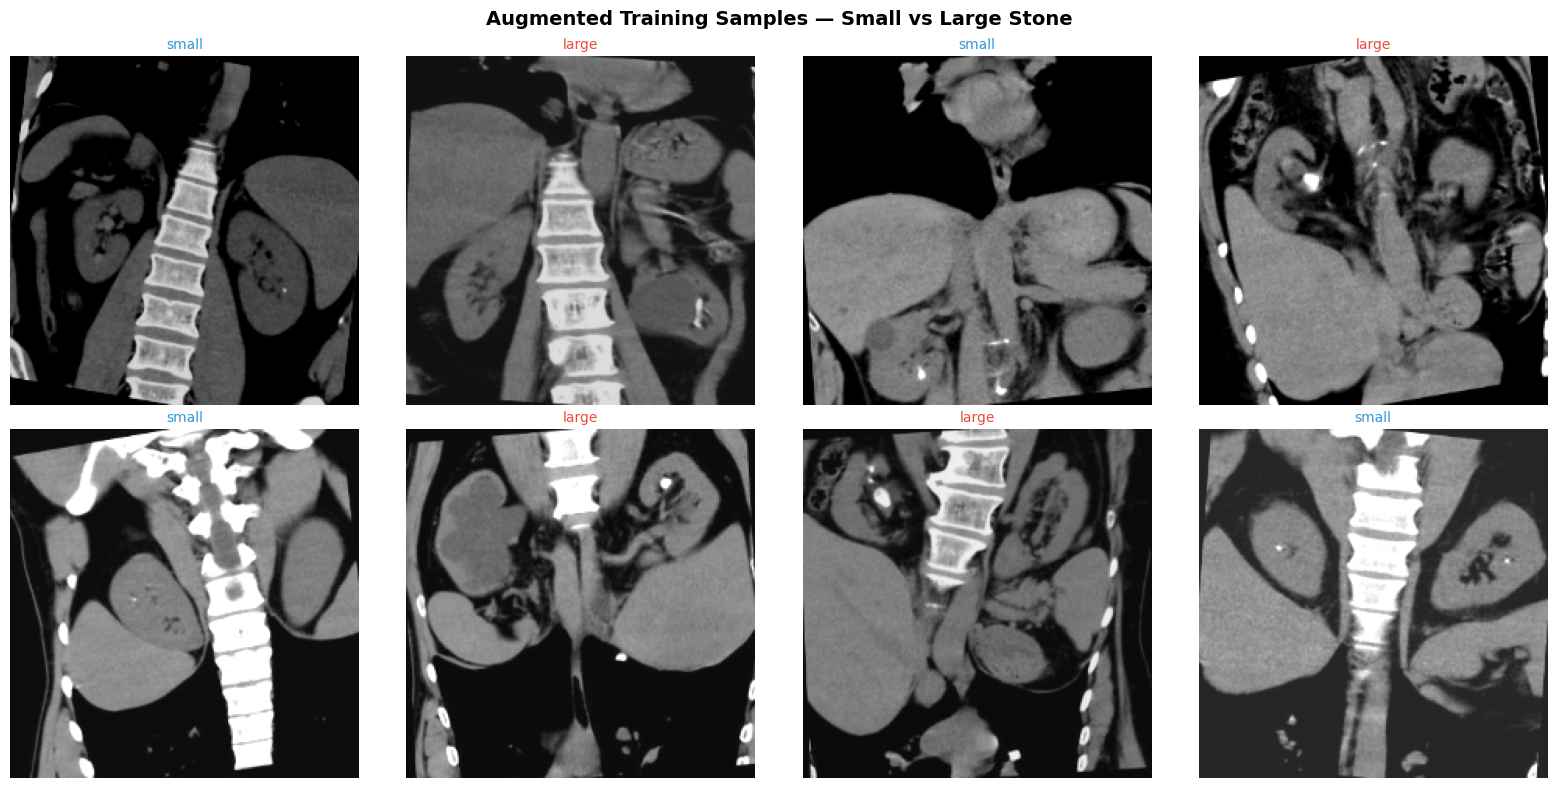

Saved: eda_augmented_samples.png


In [8]:
sample_imgs, sample_lbls = next(iter(train_ds))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Augmented Training Samples — Small vs Large Stone', fontsize=14, fontweight='bold')
for i in range(8):
    ax  = axes[i // 4][i % 4]
    ax.imshow(sample_imgs[i].numpy())
    lbl = CLASS_NAMES[int(sample_lbls[i])]
    ax.set_title(lbl, fontsize=10,
                 color='#3498db' if lbl == 'small' else '#e74c3c')
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/eda_augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_augmented_samples.png')

##  Cell 9 - Shared Utilities

In [9]:
histories = {}
COLORS    = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'/kaggle/working/{name}_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-7, verbose=1)
    ]

def merge_histories(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

METRICS = [
    'accuracy',
    keras.metrics.AUC(name='auc'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall')
]

print('Utilities ready.')

Utilities ready.


---
##  Cell 10 - Model 1: Xception

In [10]:
print('=' * 55)
print('  MODEL 1 : Xception')
print('=' * 55)
tf.keras.backend.clear_session()

base = Xception(weights='imagenet', include_top=False,
                input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

xception_model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='Xception')

xception_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy', metrics=METRICS
)

print('\n── Phase 1: Train classifier head (base frozen) ──')
h1 = xception_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('xception_p1'), verbose=1
)

print('\n── Phase 2: Fine-tune top 30 layers ──')
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
xception_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy', metrics=METRICS
)
h2 = xception_model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('xception'), verbose=1
)

histories['Xception'] = merge_histories(h1, h2)
xception_model.save('/kaggle/working/xception_final.keras')
with open('/kaggle/working/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)
print('\n✅ Xception saved!')

  MODEL 1 : Xception
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

── Phase 1: Train classifier head (base frozen) ──
Epoch 1/10


I0000 00:00:1780382665.899513      71 service.cc:152] XLA service 0x7ebb0000f6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780382665.899568      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780382665.899575      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780382667.200183      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-02 06:44:36.043409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:44:36.224463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:44:38.172672: E external/local_xl

32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5682 - auc: 0.5667 - loss: 0.9627 - precision: 0.5625 - recall: 0.6004

2026-06-02 06:44:57.642392: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:44:57.819699: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:44:59.654333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:44:59.793215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:45:00.956831: E external/local_xla/xla/stream_

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.5692 - auc: 0.5684 - loss: 0.9601 - precision: 0.5637 - recall: 0.6008

...

33/33 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6021 - auc: 0.6232 - loss: 0.8767 - precision: 0.5996 - recall: 0.6122 - val_accuracy: 0.5366 - val_auc: 0.6018 - val_loss: 0.6845 - val_precision: 0.5926 - val_recall: 0.2581 - learning_rate: 0.0010
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.7123 - auc: 0.7898 - loss: 0.6047 - precision: 0.7140 - recall: 0.7072 - val_accuracy: 0.5772 - val_auc: 0.6311 - val_loss: 0.6845 - val_precision: 0.6923 - val_recall: 0.2903 - learning_rate: 0.0010
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.7759 - auc: 0.8549 - loss: 0.4860 - precision: 0.7866 - recall: 0.7567 - val_accuracy: 0.5854 - val_auc: 0.6809 - val_loss: 0.6438 - val_precision: 0.5965 - val_recall: 0.5484 - learning_rate: 0.0010
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.8291 - auc: 0.9084 - loss: 0.3887 - precision: 0.8392 - recall: 0.8137 - val_accuracy: 0.5447 - val_auc: 0.6433 - val_loss: 0.6597 - val_precision: 0

2026-06-02 06:46:17.829634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:46:17.970768: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.6603 - auc: 0.7249 - loss: 0.6728 - precision: 0.6496 - recall: 0.6917

2026-06-02 06:46:35.186693: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:46:35.326800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 47s 823ms/step - accuracy: 0.6752 - auc: 0.7460 - loss: 0.6336 - precision: 0.6689 - recall: 0.6871 - val_accuracy: 0.6423 - val_auc: 0.6768 - val_loss: 0.6521 - val_precision: 0.6324 - val_recall: 0.6935 - learning_rate: 1.0000e-05
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step - accuracy: 0.7037 - auc: 0.7781 - loss: 0.5942 - precision: 0.7011 - recall: 0.7091 - val_accuracy: 0.6504 - val_auc: 0.6746 - val_loss: 0.6622 - val_precision: 0.6234 - val_recall: 0.7742 - learning_rate: 1.0000e-05
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step - accuracy: 0.7512 - auc: 0.8317 - loss: 0.5120 - precision: 0.7538 - recall: 0.7452 - val_accuracy: 0.6504 - val_auc: 0.6815 - val_loss: 0.6697 - val_precision: 0.6203 - val_recall: 0.7903 - learning_rate: 1.0000e-05
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8056 - auc: 0.8768 - loss: 0.4490 - precision: 0.8093 - recall: 0.7931
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.99999992

---
##  Cell 11 - Model 2: InceptionV3

In [11]:
print('=' * 55)
print('  MODEL 2 : InceptionV3')
print('=' * 55)
tf.keras.backend.clear_session()

base = InceptionV3(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

inception_model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='InceptionV3')

inception_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy', metrics=METRICS
)

print('\n── Phase 1: head only ──')
h1 = inception_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('inception_p1'), verbose=1
)

print('\n── Phase 2: fine-tune top 30 layers ──')
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
inception_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy', metrics=METRICS
)
h2 = inception_model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('inceptionv3'), verbose=1
)

histories['InceptionV3'] = merge_histories(h1, h2)
inception_model.save('/kaggle/working/inceptionv3_final.keras')
with open('/kaggle/working/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)
print('\n✅ InceptionV3 saved!')

  MODEL 2 : InceptionV3
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

── Phase 1: head only ──
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 834ms/step - accuracy: 0.5850 - auc: 0.6340 - loss: 0.8198 - precision: 0.5891 - recall: 0.6071 - val_accuracy: 0.5772 - val_auc: 0.6309 - val_loss: 0.6782 - val_precision: 0.6042 - val_recall: 0.4677 - learning_rate: 0.0010
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.7588 - auc: 0.8317 - loss: 0.5318 - precision: 0.7586 - recall: 0.7586 - val_accuracy: 0.6260 - val_auc: 0.7369 - val_loss: 0.6304 - val_precision: 0.6905 - val_recall: 0.4677 - learning_rate: 0.0010
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.8101 - auc: 0.8923 - loss: 0.4223 - precision: 0.8052 - recall: 0.8175 - val_accuracy: 0.6829 - val_auc: 0.7528 - val_loss: 0.6027 - val_precision: 0.6620 - val_recall: 0.7581 - learning_rate: 0.0010
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.8746 - auc: 0.9400 - loss: 0.3152 

---
##  Cell 12 - Model 3: EfficientNetV2S

In [12]:
print('=' * 55)
print('  MODEL 3 : EfficientNetV2S')
print('=' * 55)
tf.keras.backend.clear_session()

base = EfficientNetV2S(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

efficientnet_model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='EfficientNetV2S')

efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy', metrics=METRICS
)

print('\n── Phase 1: head only ──')
h1 = efficientnet_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('efficientnet_p1'), verbose=1
)

print('\n── Phase 2: fine-tune top 30 layers ──')
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy', metrics=METRICS
)
h2 = efficientnet_model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('efficientnetv2s'), verbose=1
)

histories['EfficientNetV2S'] = merge_histories(h1, h2)
efficientnet_model.save('/kaggle/working/efficientnetv2s_final.keras')
with open('/kaggle/working/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)
print('\n✅ EfficientNetV2S saved!')

  MODEL 3 : EfficientNetV2S
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

── Phase 1: head only ──
Epoch 1/10


2026-06-02 06:50:19.933865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:50:20.074407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:50:20.944209: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:50:21.088443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5163 - auc: 0.5881 - loss: 0.8677 - precision: 0.5610 - recall: 0.5514

2026-06-02 06:50:51.245972: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:50:51.386074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:50:52.264128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:50:52.406979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.5168 - auc: 0.5876 - loss: 0.8691 - precision: 0.5605 - recall: 0.5517

2026-06-02 06:51:22.706922: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:51:22.843815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:51:23.722416: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:51:23.863874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.5337 - auc: 0.5716 - loss: 0.9162 - precision: 0.5474 - recall: 0.5595 - val_accuracy: 0.5691 - val_auc: 0.6173 - val_loss: 0.6858 - val_precision: 0.5918 - val_recall: 0.4677 - learning_rate: 0.0010
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.5964 - auc: 0.6103 - loss: 0.8289 - precision: 0.6004 - recall: 0.5741 - val_accuracy: 0.5041 - val_auc: 0.5143 - val_loss: 0.6922 - val_precision: 0.5094 - val_recall: 0.4355 - learning_rate: 0.0010
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.5489 - auc: 0.5893 - loss: 0.8237 - precision: 0.5482 - recall: 0.5513 - val_accuracy: 0.6016 - val_auc: 0.5814 - val_loss: 0.6864 - val_precision: 0.6140 - val_recall: 0.5645 - learning_rate: 0.0010
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5515 - auc: 0.5620 - loss: 0.8704 - precision: 0.5451 - recall: 0.5593
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
3

---
##  Cell 13 - Model 4: ConvNeXt-Tiny

In [13]:
print('=' * 55)
print('  MODEL 4 : ConvNeXt-Tiny')
print('=' * 55)
tf.keras.backend.clear_session()

base = ConvNeXtTiny(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

convnext_model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='ConvNeXtTiny')

convnext_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy', metrics=METRICS
)

print('\n── Phase 1: head only ──')
h1 = convnext_model.fit(
    train_ds, epochs=10,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('convnext_p1'), verbose=1
)

print('\n── Phase 2: fine-tune top 30 layers ──')
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
convnext_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy', metrics=METRICS
)
h2 = convnext_model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds, validation_steps=len(val_ds),
    class_weight=class_weight,
    callbacks=get_callbacks('convnexttiny'), verbose=1
)

histories['ConvNeXtTiny'] = merge_histories(h1, h2)
convnext_model.save('/kaggle/working/convnexttiny_final.keras')
with open('/kaggle/working/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)
print('\n✅ ConvNeXtTiny saved!')

  MODEL 4 : ConvNeXt-Tiny
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

── Phase 1: head only ──
Epoch 1/10


2026-06-02 06:54:34.562069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:54:34.697418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5449 - auc: 0.5803 - loss: 0.7767 - precision: 0.5665 - recall: 0.5426

2026-06-02 06:54:47.115604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:54:47.251459: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.5457 - auc: 0.5810 - loss: 0.7767 - precision: 0.5668 - recall: 0.5437

2026-06-02 06:54:58.618772: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 06:54:58.754569: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 749ms/step - accuracy: 0.5708 - auc: 0.6028 - loss: 0.7744 - precision: 0.5753 - recall: 0.5782 - val_accuracy: 0.4959 - val_auc: 0.7163 - val_loss: 0.6900 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.7142 - auc: 0.7774 - loss: 0.5732 - precision: 0.7184 - recall: 0.7034 - val_accuracy: 0.5285 - val_auc: 0.7386 - val_loss: 0.6761 - val_precision: 0.5167 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - accuracy: 0.7464 - auc: 0.8234 - loss: 0.5195 - precision: 0.7476 - recall: 0.7433 - val_accuracy: 0.6423 - val_auc: 0.7730 - val_loss: 0.6522 - val_precision: 0.5978 - val_recall: 0.8871 - learning_rate: 0.0010
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.7759 - auc: 0.8539 - loss: 0.4803 - precision: 0.7726 - recall: 0.7814 - val_accuracy: 0.7154 - val_auc: 0.7812 - val_loss: 0.6421 - val_p

## Cell 14 - Training Curves (All Models)

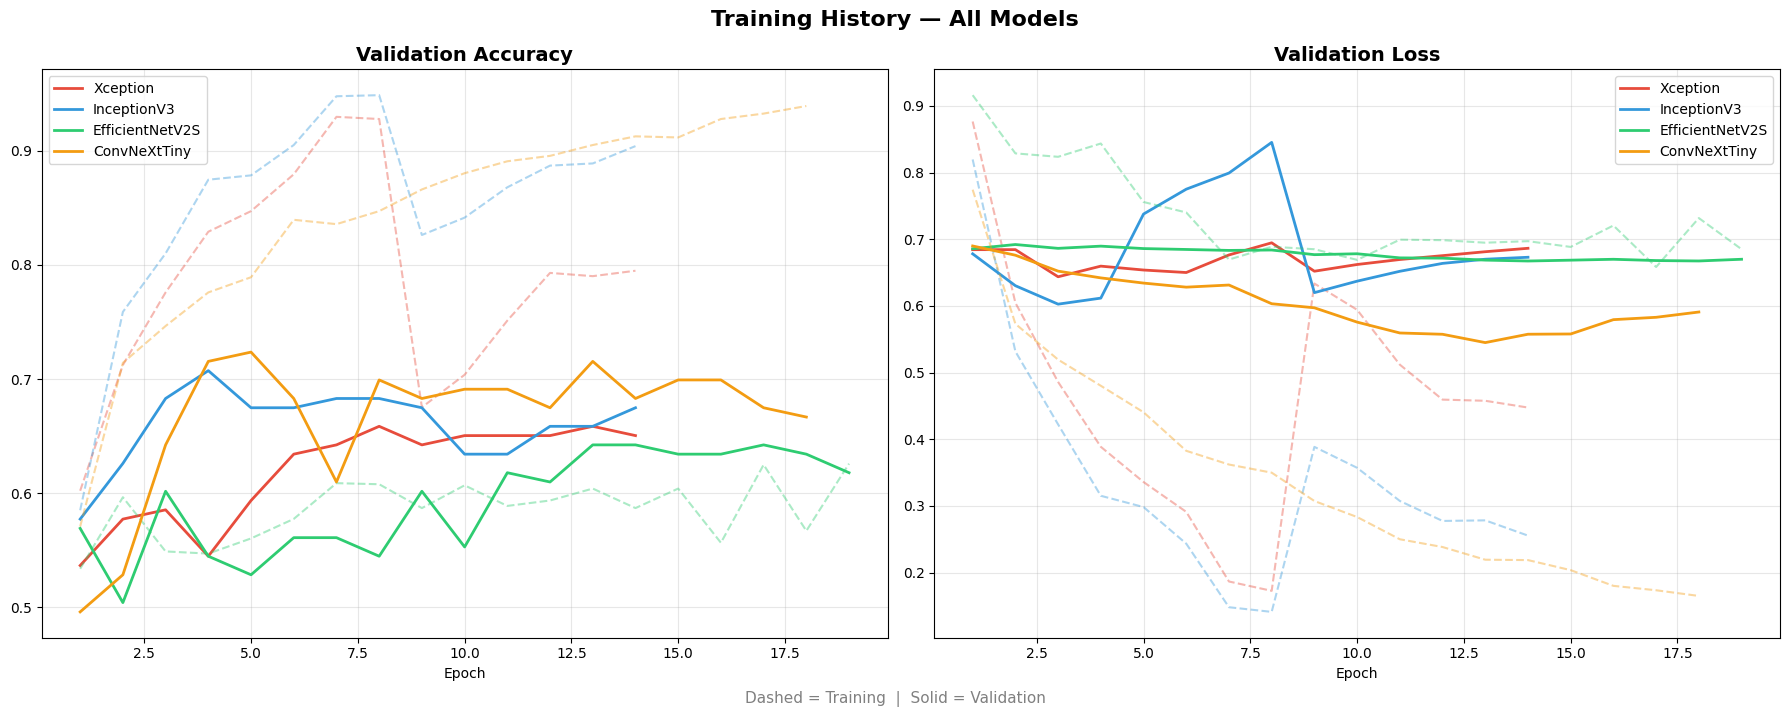

Saved: training_curves.png


In [14]:
with open('/kaggle/working/histories.pkl', 'rb') as f:
    histories = pickle.load(f)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Training History — All Models', fontsize=16, fontweight='bold')

for (name, hist), color in zip(histories.items(), COLORS):
    ep = range(1, len(hist['accuracy']) + 1)
    axes[0].plot(ep, hist['accuracy'],     '--', color=color, alpha=0.4)
    axes[0].plot(ep, hist['val_accuracy'], '-',  color=color, label=name, lw=2)
    axes[1].plot(ep, hist['loss'],         '--', color=color, alpha=0.4)
    axes[1].plot(ep, hist['val_loss'],     '-',  color=color, label=name, lw=2)

for ax, title in zip(axes, ['Validation Accuracy', 'Validation Loss']):
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Dashed = train, solid = val
fig.text(0.5, -0.01, 'Dashed = Training  |  Solid = Validation',
         ha='center', fontsize=11, color='gray')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

##  Cell 15 - Evaluation on Test Set

In [15]:
models_dict = {
    'Xception'       : keras.models.load_model('/kaggle/working/xception_final.keras'),
    'InceptionV3'    : keras.models.load_model('/kaggle/working/inceptionv3_final.keras'),
    'EfficientNetV2S': keras.models.load_model('/kaggle/working/efficientnetv2s_final.keras'),
    'ConvNeXtTiny'   : keras.models.load_model('/kaggle/working/convnexttiny_final.keras'),
}

results = {}

for name, model in models_dict.items():
    print(f'\nEvaluating: {name} ...')
    y_true, y_prob = [], []

    for imgs, lbls in test_ds:
        preds = model.predict(imgs, verbose=0).flatten()
        y_prob.extend(preds)
        y_true.extend(lbls.numpy().flatten())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    rep = classification_report(y_true, y_pred, output_dict=True,
                                target_names=CLASS_NAMES)
    try:   auc   = roc_auc_score(y_true, y_prob)
    except: auc  = float('nan')
    try:   kappa = cohen_kappa_score(y_true, y_pred)
    except: kappa = float('nan')

    results[name] = {
        'accuracy' : rep['accuracy'],
        'precision': rep['macro avg']['precision'],
        'recall'   : rep['macro avg']['recall'],
        'f1'       : rep['macro avg']['f1-score'],
        'auc'      : auc,
        'kappa'    : kappa,
        'y_true'   : y_true,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

    print(f'  Accuracy  : {rep["accuracy"]:.4f}')
    print(f'  F1-Score  : {rep["macro avg"]["f1-score"]:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  Cohen κ   : {kappa:.4f}')


Evaluating: Xception ...
  Accuracy  : 0.5447
  F1-Score  : 0.5440
  ROC-AUC   : 0.5933
  Cohen κ   : 0.0889

Evaluating: InceptionV3 ...
  Accuracy  : 0.6911
  F1-Score  : 0.6905
  ROC-AUC   : 0.7496
  Cohen κ   : 0.3817

Evaluating: EfficientNetV2S ...
  Accuracy  : 0.5935
  F1-Score  : 0.5935
  ROC-AUC   : 0.6214
  Cohen κ   : 0.1872

Evaluating: ConvNeXtTiny ...
  Accuracy  : 0.7154
  F1-Score  : 0.7136
  ROC-AUC   : 0.7501
  Cohen κ   : 0.4302


## Cell 16 - Confusion Matrices

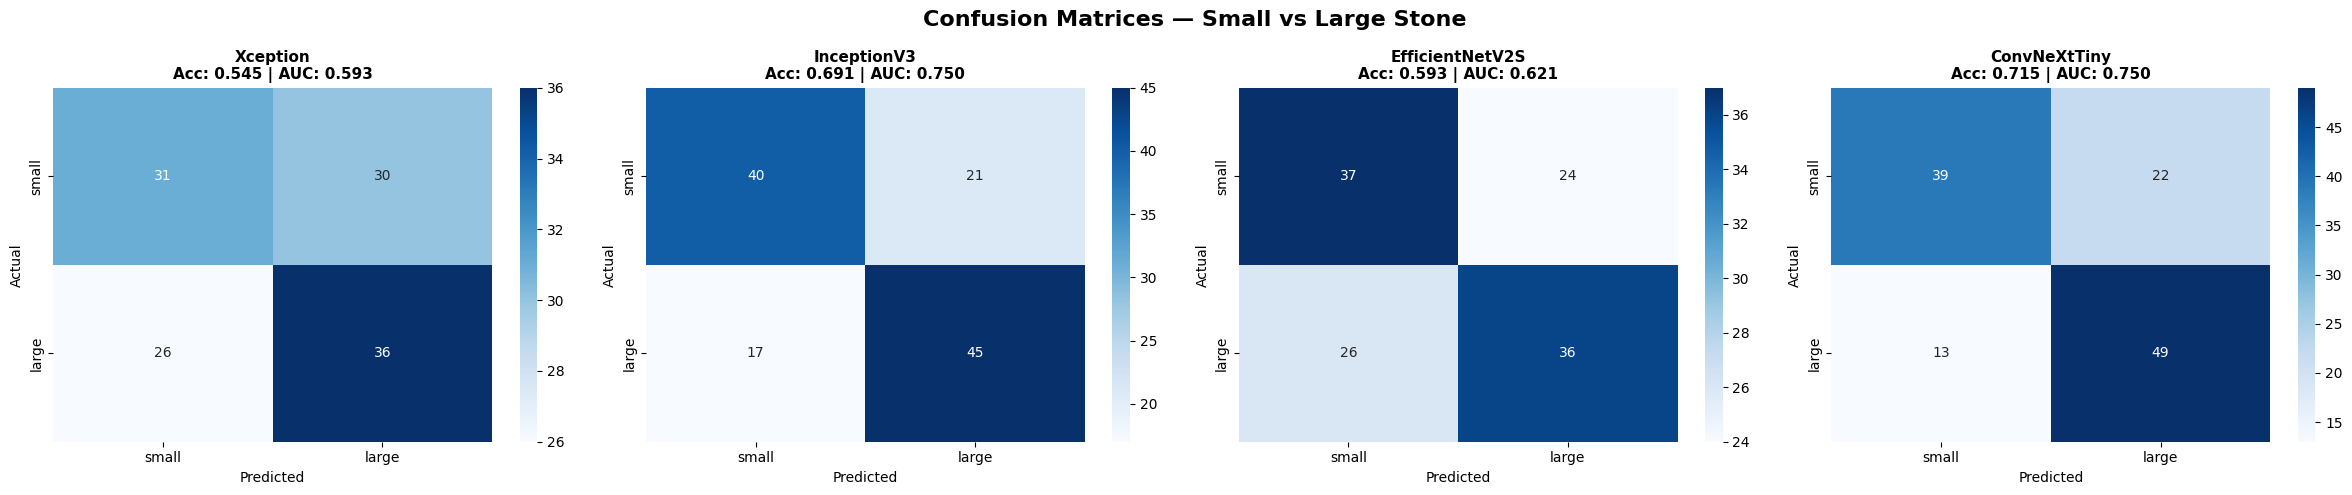

Saved: confusion_matrices.png


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('Confusion Matrices — Small vs Large Stone',
             fontsize=16, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f} | AUC: {res["auc"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

## Cell 17 - ROC Curves

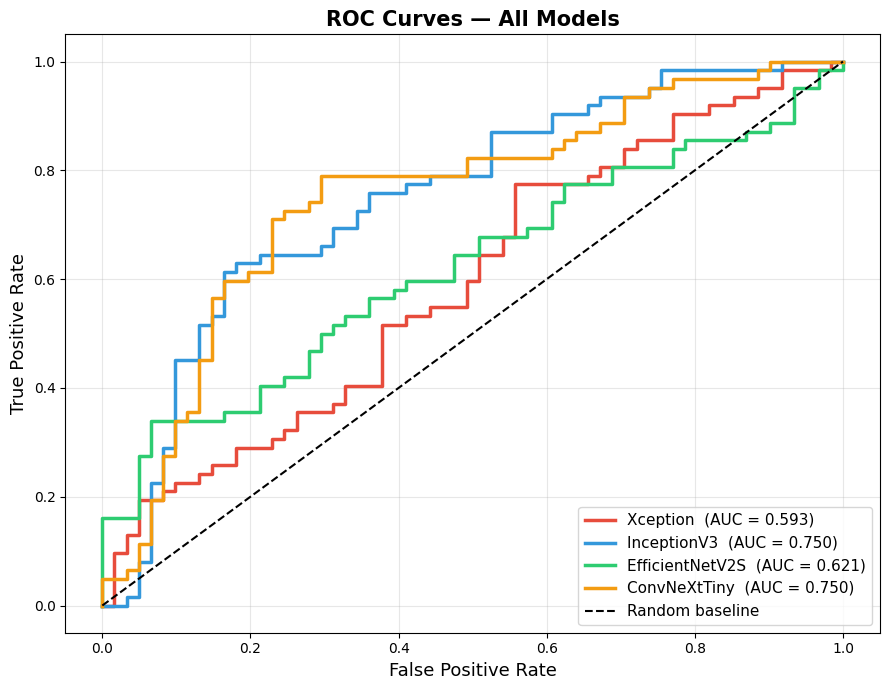

Saved: roc_curves.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 7))

for (name, res), color in zip(results.items(), COLORS):
    if len(np.unique(res['y_true'])) < 2:
        continue
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name}  (AUC = {res['auc']:.3f})")

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

##  Cell 18 - Final Comparison Table & Bar Chart

=== FINAL COMPARISON TABLE ===
                 Accuracy  Precision  Recall  F1-Score  ROC-AUC  Cohen Kappa
Xception           0.5447     0.5447  0.5444    0.5440   0.5933       0.0889
InceptionV3        0.6911     0.6918  0.6908    0.6905   0.7496       0.3817
EfficientNetV2S    0.5935     0.5937  0.5936    0.5935   0.6214       0.1872
ConvNeXtTiny       0.7154     0.7201  0.7148    0.7136   0.7501       0.4302


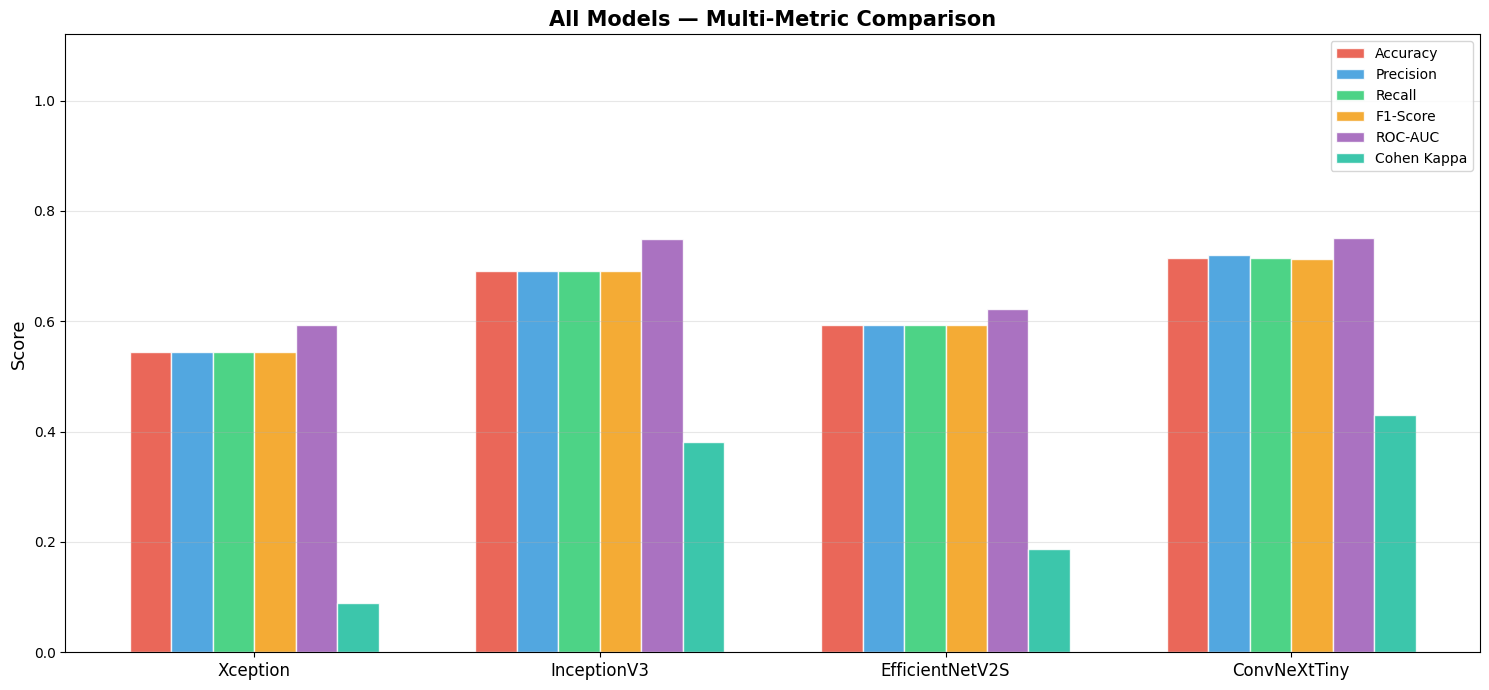

Saved: final_comparison.png


In [18]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy'    : res['accuracy'],
        'Precision'   : res['precision'],
        'Recall'      : res['recall'],
        'F1-Score'    : res['f1'],
        'ROC-AUC'     : res['auc'],
        'Cohen Kappa' : res['kappa'],
    } for name, res in results.items()
}).T.round(4)

print('=== FINAL COMPARISON TABLE ===')
print(metrics_df.to_string())

metric_cols   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Cohen Kappa']
metric_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
x = np.arange(len(metrics_df))
w = 0.12

fig, ax = plt.subplots(figsize=(15, 7))
for i, (metric, color) in enumerate(zip(metric_cols, metric_colors)):
    ax.bar(x + i*w, metrics_df[metric], w,
           label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w * 2.5)
ax.set_xticklabels(metrics_df.index, fontsize=12)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('All Models — Multi-Metric Comparison', fontsize=15, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_comparison.png')

##  Cell 19 - Conclusion

In [19]:
best = metrics_df['F1-Score'].idxmax()
b    = metrics_df.loc[best]

print('=' * 60)
print('  CONCLUSION')
print('=' * 60)
print(f'\n  Task       : Small Stone vs Large Stone Classification')
print(f'  Method     : Median bounding box area split (threshold = {df["max_area"].median():.4f})')
print(f'  Dataset    : ~{len(df)} CT scan images (train/valid/test pre-split)')
print(f'\n  Best Model : {best}')
print(f'  Accuracy   : {b["Accuracy"]:.4f}')
print(f'  F1-Score   : {b["F1-Score"]:.4f}')
print(f'  ROC-AUC    : {b["ROC-AUC"]:.4f}')
print(f'  Cohen κ    : {b["Cohen Kappa"]:.4f}')
print()
print('  All models ranked by F1-Score:')
print(metrics_df.sort_values('F1-Score', ascending=False)
          [['Accuracy','F1-Score','ROC-AUC','Cohen Kappa']].to_string())

  CONCLUSION

  Task       : Small Stone vs Large Stone Classification
  Method     : Median bounding box area split (threshold = 0.0015)
  Dataset    : ~1299 CT scan images (train/valid/test pre-split)

  Best Model : ConvNeXtTiny
  Accuracy   : 0.7154
  F1-Score   : 0.7136
  ROC-AUC    : 0.7501
  Cohen κ    : 0.4302

  All models ranked by F1-Score:
                 Accuracy  F1-Score  ROC-AUC  Cohen Kappa
ConvNeXtTiny       0.7154    0.7136   0.7501       0.4302
InceptionV3        0.6911    0.6905   0.7496       0.3817
EfficientNetV2S    0.5935    0.5935   0.6214       0.1872
Xception           0.5447    0.5440   0.5933       0.0889


---
**End of Notebook** — Kidney Stone Images Classification  
*DL-Simplified | Issue #467 | GSSoC '26*